In [4]:
%pip install xgboost shap

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 981.5 kB/s eta 0:00:50
    --------------------------------------- 0.8/48.9 MB 985.7 kB/s eta 0:00:49
    --------------------------------------- 1.0/48.9 MB 1.1 MB/s eta 0:00:4

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\MuNe\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\numba\\tests\\test_dictimpl.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   --------------------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    average_precision_score, precision_recall_curve
)
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from xgboost import XGBClassifier
import shap
import sklearn


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 1.0/48.9 MB 2.9 MB/s eta 0:00:17
   - -------------------------------------- 1.6/48.9 MB 2.8 MB/s eta 0:00:17
   - -------------------------------------- 2.1/48.9 MB 2.8 MB/s eta 0:00:17
   -- ------------------------------------- 2.9/48.9 MB 2.9 MB/s eta 0:00:17
   -- ------------------------------------- 3.4/48.9 MB 2.9 MB/s eta 0:00:16
   --- ------------------------------------ 3.9/48.9 MB 2.8 MB/s eta 0:00:16
   --- ------------------------------------ 4.7/48.9 MB 2.9 MB/s eta 0:00:16
   ---- ----------------------------------- 5.2/48.9 MB 2.8 MB/s eta 0:00:16
   ---- ----------------------------------- 5.8/48.9 MB 2.8 MB/s eta 0:00:16
   ----- ---------------------------------- 6.6/48.9 MB 2.8 MB/s eta 0:00:15
   ----- ---------------------------------- 7.1/48.9 MB 2.8 MB/s eta 0:00:15
   ------ ---


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\MuNe\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# 1. โหลดข้อมูล
df = pd.read_csv(r"C:\Users\MuNe\IBM_challenge\august_challenge\IBM_august_challenge\ml_ready_dataset.csv")
print(df.columns.tolist())
print(f"period ที่มี: {df['period'].unique()}")


C:\Users\MuNe\AppData\Local\Temp\ipykernel_34636\3569552467.py:2: DtypeWarning: Columns (0: anomaly_reason) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\MuNe\IBM_challenge\august_challenge\IBM_august_challenge\ml_ready_dataset.csv")


['period', 'bx_gse_nt', 'by_gse_nt', 'bz_gse_nt', 'theta_gse_deg', 'phi_gse_deg', 'bx_gsm_nt', 'by_gsm_nt', 'bz_gsm_nt', 'theta_gsm_deg', 'phi_gsm_deg', 'bt_total_nt', 'solar_wind_density_cm3', 'velocity_m_s', 'solar_wind_temp_k', 'timedelta_s', 'gse_x_dscovr_km', 'gse_y_dscovr_km', 'gse_z_dscovr_km', 'smoothed_sunspot_number', 'is_anomaly_flagged', 'anomaly_reason', 'newell_coupling', 'sw_dynamic_pressure_npa', 'bz_rolling_mean_3h', 'bz_rolling_min_3h', 'src_ac', 'src_ds', 'storm_sev_extreme', 'storm_sev_intense', 'storm_sev_moderate', 'storm_sev_minor', 'storm_sev_quiet', 'storm_sev_positive', 'sw_spd_slow', 'sw_spd_normal', 'sw_spd_fast', 'sw_spd_very_fast', 'sw_spd_extreme', 'radio_flux_107_sfu_mean', 'flares_m_count_sum', 'flares_x_count_sum', 'xray_flux_numeric_max', 'global_surface_temp_c', 'global_surface_humidity_pct', 'global_surface_pressure_hpa', 'global_surface_wind_speed_knots', 'global_cloud_cover_pct']
period ที่มี: <StringArray>
['train_a', 'train_b', 'train_c']
Length

In [9]:
df["target_a_anomaly"] = np.where(df["is_anomaly_flagged"] == 1, 0, 1)  # 0=NO-GO, 1=GO

df["target_b_rule"] = np.where(
    (df["storm_sev_intense"] == 1) | (df["storm_sev_extreme"] == 1) | (df["flares_x_count_sum"] > 0),
    0, 1
)

print("=== Target A (is_anomaly_flagged) ===")
print(df["target_a_anomaly"].value_counts())
print(f"สัดส่วน NO-GO: {(df['target_a_anomaly']==0).mean()*100:.4f}%\n")

print("=== Target B (rule-based storm severity / X-flare) ===")
print(df["target_b_rule"].value_counts())
print(f"สัดส่วน NO-GO: {(df['target_b_rule']==0).mean()*100:.4f}%")

=== Target A (is_anomaly_flagged) ===
target_a_anomaly
1    8384525
0       7795
Name: count, dtype: int64
สัดส่วน NO-GO: 0.0929%

=== Target B (rule-based storm severity / X-flare) ===
target_b_rule
1    5236655
0    3155665
Name: count, dtype: int64
สัดส่วน NO-GO: 37.6018%


In [12]:
# 3. เรียงตามเวลา + สร้าง Feature เชิงการเปลี่ยนแปลง
# เพิ่ม rolling window ยาวขึ้น (30, 60 จุด) สำหรับตัวแปรที่เป็น leading indicator ทางฟิสิกส์
# ของพายุแม่เหล็ก/solar wind (โดยเฉพาะ bz ติดลบต่อเนื่อง มักเป็นสัญญาณเตือนล่วงหน้า)
if "period" in df.columns:
    df = df.sort_values(["period"]).reset_index(drop=True)

exclude_from_diff = ["target_a_anomaly", "target_b_rule", "is_anomaly_flagged",
                      "anomaly_reason", "period", "dst_index_nt", "flares_x_count_sum"]
base_numeric_cols = [
    col for col in df.columns
    if col not in exclude_from_diff and df[col].dtype in [np.float64, np.int64, np.int32]
]

for col in base_numeric_cols:
    df[f"{col}_diff"] = df[col].diff().fillna(0)
    df[f"{col}_roll_std5"] = df[col].rolling(5).std().fillna(0)

leading_indicator_cols = [c for c in ["bz_gsm_nt", "bt_total_nt", "velocity_m_s", "solar_wind_density_cm3"]
                           if c in df.columns]
for col in leading_indicator_cols:
    df[f"{col}_roll_mean30"] = df[col].rolling(30).mean().bfill()
    df[f"{col}_roll_min60"] = df[col].rolling(60).min().bfill()

# has_anomaly_reason แทบเป็นสำเนาของ is_anomaly_flagged (มีค่าก็ต่อเมื่อ flag=1 เท่านั้น)
# เก็บไว้ดูอ้างอิงได้ แต่ห้ามใช้เป็น feature ของ target A เด็ดขาด (จะ leak)
df["has_anomaly_reason"] = df["anomaly_reason"].notna().astype(int)

# แบ่งแต่ละ period ออกเป็นช่วงย่อยตามลำดับเวลา เพื่อให้มี "group" มากพอสำหรับ
# cross-validation ที่มีความหมาย (period ดิบมีแค่ 3 กลุ่ม ซึ่งน้อยเกินไป)
n_subgroups_per_period = 10
df["period_sub"] = (
    df["period"].astype(str) + "_" +
    df.groupby("period").cumcount().div(
        df.groupby("period")["period"].transform("size")
    ).mul(n_subgroups_per_period).astype(int).astype(str)
)

print(f"เพิ่ม feature ใหม่แล้ว รวมทั้งหมด {df.shape[1]} คอลัมน์")
print(f"จำนวน period_sub groups: {df['period_sub'].nunique()}")


C:\Users\MuNe\AppData\Local\Temp\ipykernel_34636\2636136775.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_diff"] = df[col].diff().fillna(0)
C:\Users\MuNe\AppData\Local\Temp\ipykernel_34636\2636136775.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_roll_std5"] = df[col].rolling(5).std().fillna(0)
C:\Users\MuNe\AppData\Local\Temp\ipykernel_34636\2636136775.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

เพิ่ม feature ใหม่แล้ว รวมทั้งหมด 122 คอลัมน์
จำนวน period_sub groups: 30


In [13]:
# 4. เตรียม Features แยกสำหรับแต่ละ target (กัน leakage คนละแบบ)
groups = df["period_sub"]

# --- Target A: ตัด is_anomaly_flagged, anomaly_reason, has_anomaly_reason ---
# has_anomaly_reason แทบเป็นสำเนาของ label (มีค่าก็ต่อเมื่อ flag=1) จึงต้องตัดออกด้วย
# ไม่งั้นจะเกิด leakage แบบเดิมที่ทำให้ PR-AUC ออกมา 1.0000 ทั้งที่ไม่ได้เรียนรู้อะไรจริง
drop_cols_a = ["target_a_anomaly", "target_b_rule", "is_anomaly_flagged", "anomaly_reason",
               "has_anomaly_reason", "period", "period_sub"]
feature_cols_a = [c for c in df.columns if c not in drop_cols_a and df[c].dtype in [np.float64, np.int64, np.int32]]
X_a = df[feature_cols_a].astype(np.float64)
y_a = df["target_a_anomaly"]

# --- Target B: ตัด dst_index_nt, flares_x_count_sum (ตัวที่ใช้สร้าง label โดยตรง) ---
drop_cols_b = ["target_a_anomaly", "target_b_rule", "anomaly_reason", "has_anomaly_reason",
               "period", "period_sub", "dst_index_nt", "flares_x_count_sum"]
feature_cols_b = [c for c in df.columns if c not in drop_cols_b and df[c].dtype in [np.float64, np.int64, np.int32]]
X_b = df[feature_cols_b].astype(np.float64)
y_b = df["target_b_rule"]

print(f"Target A -> {len(feature_cols_a)} features")
print(f"Target B -> {len(feature_cols_b)} features")


Target A -> 102 features
Target B -> 102 features


In [14]:
# 4b. ตรวจสอบ Leakage ด้วย Correlation (ใช้ sample + corrwith แทน .corr() เต็มรูปแบบ
# เพื่อประหยัด memory มาก เพราะ .corr() จะสร้าง correlation matrix ทุกคู่ feature
# ซึ่งไม่จำเป็นและกิน RAM มหาศาลกับข้อมูล 8+ ล้านแถว
sample_size = min(500_000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

corr_a = df_sample[feature_cols_a].corrwith(df_sample["target_a_anomaly"]).abs().sort_values(ascending=False)
print("=== Top correlation กับ Target A (จาก sample) ===")
print(corr_a.head(10))

corr_b = df_sample[feature_cols_b].corrwith(df_sample["target_b_rule"]).abs().sort_values(ascending=False)
print("\n=== Top correlation กับ Target B (จาก sample) ===")
print(corr_b.head(10))

del df_sample  # คืน memory ทันทีหลังใช้เสร็จ


c:\Users\MuNe\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\MuNe\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


=== Top correlation กับ Target A (จาก sample) ===
solar_wind_density_cm3                0.300215
sw_dynamic_pressure_npa               0.220277
solar_wind_density_cm3_roll_std5      0.207505
solar_wind_density_cm3_roll_mean30    0.203924
sw_dynamic_pressure_npa_roll_std5     0.169530
solar_wind_density_cm3_diff           0.134775
bt_total_nt                           0.126017
bt_total_nt_roll_mean30               0.122569
bz_rolling_min_3h                     0.117058
bz_gsm_nt_roll_min60                  0.104950
dtype: float64

=== Top correlation กับ Target B (จาก sample) ===
xray_flux_numeric_max                 0.975650
flares_m_count_sum                    0.942801
gse_y_dscovr_km                       0.559632
solar_wind_density_cm3_roll_min60     0.276819
gse_z_dscovr_km                       0.256141
solar_wind_density_cm3_roll_mean30    0.240673
sw_dynamic_pressure_npa               0.229943
solar_wind_density_cm3                0.222083
gse_x_dscovr_km                       

In [15]:
# 5. ฟังก์ชันช่วย: holdout split + cross-validation + evaluation (ใช้ซ้ำได้ทั้ง A และ B)
def run_full_pipeline(X, y, groups, label_name, n_splits=5, top_n=500):
    print(f"\n{'='*20} {label_name} {'='*20}")

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train_full = groups.iloc[train_idx]

    print(f"Train: {X_train_full.shape}, Holdout Test: {X_test.shape}")
    print("y_test distribution:", y_test.value_counts().to_dict())

    n_unique_groups = groups_train_full.nunique()
    actual_n_splits = min(n_splits, n_unique_groups)
    fold_pr_auc = []

    if actual_n_splits < 2:
        print(f"  [WARNING] มี group แค่ {n_unique_groups} กลุ่มในฝั่ง train ข้าม cross-validation")
    else:
        if actual_n_splits < n_splits:
            print(f"  [WARNING] ปรับ n_splits จาก {n_splits} เป็น {actual_n_splits} ตามจำนวน group ที่มี")

        gkf = GroupKFold(n_splits=actual_n_splits)
        for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train_full, y_train_full, groups=groups_train_full)):
            X_tr, X_val = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
            y_tr, y_val = y_train_full.iloc[tr_idx], y_train_full.iloc[val_idx]
            if y_val.nunique() < 2 or y_tr.nunique() < 2:
                print(f"  [Fold {fold+1}] ข้าม เพราะ train/val มีคลาสเดียว")
                continue
            fold_model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                        enable_categorical=False, random_state=42)
            fold_model.fit(X_tr, y_tr)
            val_prob0 = 1 - fold_model.predict_proba(X_val)[:, 1]
            pr_auc = average_precision_score(y_val, val_prob0, pos_label=0)
            fold_pr_auc.append(pr_auc)
            print(f"  [Fold {fold+1}] PR-AUC (class 0): {pr_auc:.4f}")

    cv_mean = np.nanmean(fold_pr_auc) if fold_pr_auc else np.nan
    cv_std = np.nanstd(fold_pr_auc) if fold_pr_auc else np.nan
    print(f"  PR-AUC เฉลี่ยจาก {len(fold_pr_auc)} folds: {cv_mean:.4f} (+/- {cv_std:.4f})")

    # --- เทรนโมเดลสุดท้ายด้วย train ทั้งหมด ประเมินบน holdout ---
    model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                           enable_categorical=False, random_state=42)
    model.fit(X_train_full, y_train_full)

    y_prob = model.predict_proba(X_test)[:, 1]
    prob_class0 = 1 - y_prob
    y_pred = model.predict(X_test)

    print("\n  --- Holdout Test (threshold 0.5) ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=["NO-GO (0)", "GO (1)"], zero_division=0))

    # ตรวจสอบว่าโมเดลเรียนรู้อะไรจริงไหม (ไม่ใช่แค่ทายค่าเดียวซ้ำๆ)
    print(f"  Probability (class 0) distribution: min={prob_class0.min():.4f}, "
          f"max={prob_class0.max():.4f}, std={prob_class0.std():.4f}")
    if prob_class0.std() < 1e-4:
        print("  [WARNING] Probability แทบไม่กระจายตัวเลย -> โมเดลไม่ได้เรียนรู้ pattern ใดๆ จริง")

    pr_auc_holdout = average_precision_score(y_test, prob_class0, pos_label=0)
    print(f"  PR-AUC (holdout, class 0): {pr_auc_holdout:.4f}")

    top_k = min(top_n, len(prob_class0))
    top_idx = np.argsort(prob_class0)[::-1][:top_k]
    caught = (y_test.iloc[top_idx] == 0).sum()
    total_nogo = (y_test == 0).sum()
    print(f"  Precision@{top_k}: จับได้ {caught}/{total_nogo} ({caught/top_k:.4f})")

    return {
        "model": model, "X_train": X_train_full, "X_test": X_test, "y_test": y_test,
        "cv_pr_auc_mean": cv_mean, "cv_pr_auc_std": cv_std, "holdout_pr_auc": pr_auc_holdout
    }


In [16]:
# 6. รันทั้งสองแนวทางแล้วเปรียบเทียบ
result_a = run_full_pipeline(X_a, y_a, groups, "TARGET A: is_anomaly_flagged")
result_b = run_full_pipeline(X_b, y_b, groups, "TARGET B: rule-based (Dst/flare)")

print(f"\n{'='*50}")
print("=== สรุปเปรียบเทียบ ===")
print(f"Target A -> CV PR-AUC: {result_a['cv_pr_auc_mean']:.4f} (+/-{result_a['cv_pr_auc_std']:.4f}), "
      f"Holdout PR-AUC: {result_a['holdout_pr_auc']:.4f}")
print(f"Target B -> CV PR-AUC: {result_b['cv_pr_auc_mean']:.4f} (+/-{result_b['cv_pr_auc_std']:.4f}), "
      f"Holdout PR-AUC: {result_b['holdout_pr_auc']:.4f}")
print("\nหมายเหตุ: Target B วัดว่า 'สัญญาณอื่นที่ไม่ใช่ Dst/flare โดยตรง' (สนามแม่เหล็ก, solar wind, "
      "sunspot) เป็นตัวเตือนล่วงหน้าของความเสี่ยงแบบเดียวกันได้ดีแค่ไหน ถ้า PR-AUC ของ B ยังต่ำมาก "
      "หลังเพิ่ม rolling window ยาวขึ้นแล้ว แปลว่าด้วยฟีเจอร์ที่มีอยู่ตอนนี้ ยังไม่มีสัญญาณเตือนล่วงหน้า "
      "ที่ชัดเจนพอในข้อมูลสนามแม่เหล็ก/solar wind ที่เก็บมา")



==================== TARGET A: is_anomaly_flagged ====================
Train: (6713856, 102), Holdout Test: (1678464, 102)
y_test distribution: {1: 1677419, 0: 1045}
  [Fold 1] PR-AUC (class 0): 0.6146
  [Fold 2] PR-AUC (class 0): 0.2004
  [Fold 3] PR-AUC (class 0): 0.5808
  [Fold 4] PR-AUC (class 0): 0.5280
  [Fold 5] PR-AUC (class 0): 0.5911
  PR-AUC เฉลี่ยจาก 5 folds: 0.5030 (+/- 0.1539)

  --- Holdout Test (threshold 0.5) ---
[[    467     578]
 [    165 1677254]]
              precision    recall  f1-score   support

   NO-GO (0)       0.74      0.45      0.56      1045
      GO (1)       1.00      1.00      1.00   1677419

    accuracy                           1.00   1678464
   macro avg       0.87      0.72      0.78   1678464
weighted avg       1.00      1.00      1.00   1678464

  Probability (class 0) distribution: min=0.0000, max=1.0000, std=0.0169
  PR-AUC (holdout, class 0): 0.5415
  Precision@500: จับได้ 382/1045 (0.7640)

==================== TARGET B: rule-based (Dst/

Background dataset has 6713856 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6713856 when initializing the masker.


SHAP Summary: Target A (is_anomaly_flagged)


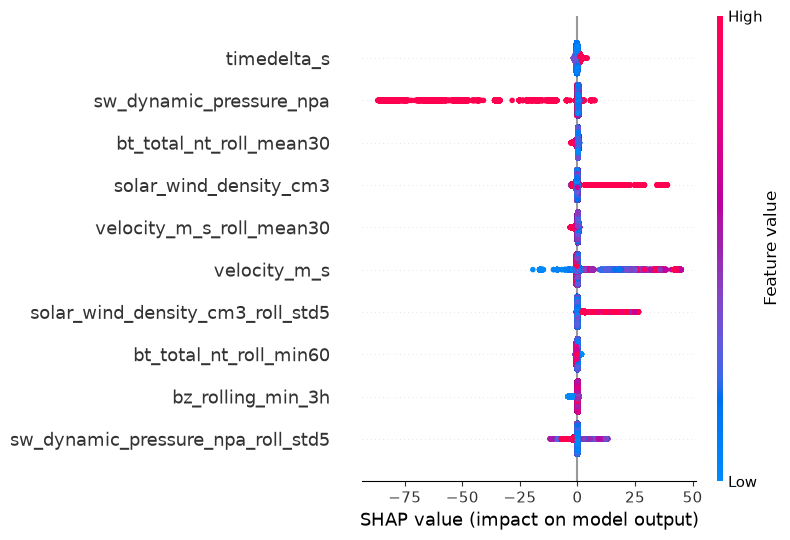

In [17]:
# 7. SHAP Analysis เปรียบเทียบ - ดูว่าฟีเจอร์ไหนสำคัญกับความเสี่ยงในแต่ละแนวทาง
explainer_a = shap.Explainer(result_a["model"], result_a["X_train"], feature_perturbation="tree_path_dependent")
shap_values_a = explainer_a(result_a["X_test"])

print("SHAP Summary: Target A (is_anomaly_flagged)")
shap.summary_plot(shap_values_a, result_a["X_test"], max_display=10)


Background dataset has 6713856 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6713856 when initializing the masker.


SHAP Summary: Target B (rule-based Dst/flare)


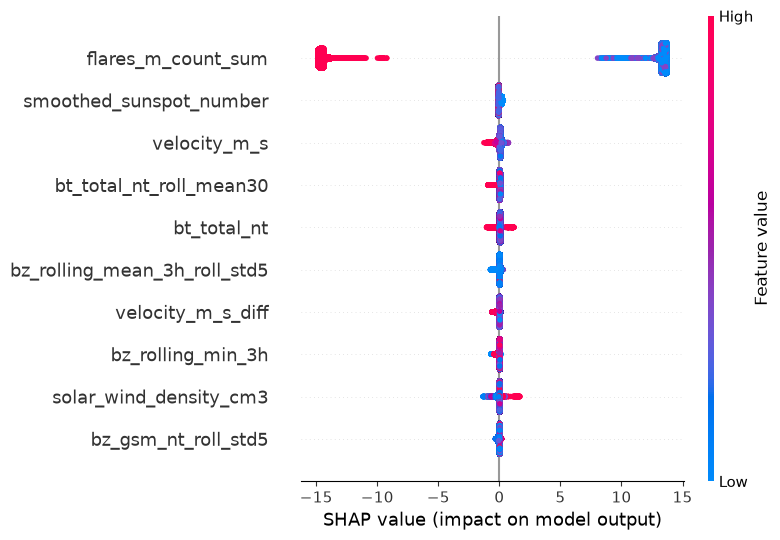

In [18]:
explainer_b = shap.Explainer(result_b["model"], result_b["X_train"], feature_perturbation="tree_path_dependent")
shap_values_b = explainer_b(result_b["X_test"])

print("SHAP Summary: Target B (rule-based Dst/flare)")
shap.summary_plot(shap_values_b, result_b["X_test"], max_display=10)
